In [4]:
!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 869.2 kB/s eta 0:01:23
   ---------------------------------------- 0.5/72.0 MB 869.2 kB/s eta 0:01:23
   ---------------------------------------- 0.8/72.0 MB 747.5 kB/s eta 0:01:36
    --------------------------------------- 1.0/72.0 MB 856.2 kB/s eta 0:01:23
    --------------------------------------- 1.3/72.0 MB 956.6 kB/s eta 0:01:14
    --------------------------------------- 1.6/72.0 MB 1.1 MB/s eta 0:01:06
   - -------------------------------------- 1.8/72.0 MB 1.0 MB/s eta 0:01:08
   - -------------------------------------- 2.1/72.0 MB 1.1 MB/s eta 0:01:05
   - -------------------------------------- 2.6/72.0 MB 1.2 MB/s eta 0:01:00
   - -------------------------------------- 3.1/72.0 MB 1.3 MB/s eta 0:00:54
   -- ----

In [9]:
#import nessecery libraries
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time

In [16]:
#load the California housing dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

#seprate training testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 35)

In [22]:
# train the RandomForest model
rfr = RandomForestRegressor()

rfr_model = rfr.fit(X_train, y_train)

y_pred = rfr.predict(X_test)

In [23]:
#testing the accuracy of the RandomForestRegressor
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error: 0.26
R² Score: 0.81


In [25]:
# train the XGBoost model
xgb = XGBRegressor()

xgb_model = xgb.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [27]:
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"Mean Squared Error: {mse_xgb:.2f}")
print(f"R² Score: {r2_xgb:.2f}")

Mean Squared Error: 0.22
R² Score: 0.84


In [29]:
 #Measure prediction time for Random Forest
start_time_rf = time.time()
y_pred_rf = rfr_model.predict(X_test)
end_time_rf = time.time()
rf_pred_time = end_time_rf - start_time_rf

# Measure prediciton time for XGBoost
start_time_xgb = time.time()
y_pred_xgb = xgb_model.predict(X_test)
end_time_xgb = time.time()
xgb_pred_time = end_time_xgb - start_time_xgb

print("RandomForest : ", rf_pred_time)
print("XGBoost : ", xgb_pred_time)

RandomForest :  0.26482605934143066
XGBoost :  0.012452363967895508


In [31]:
std_y = np.std(y_test)

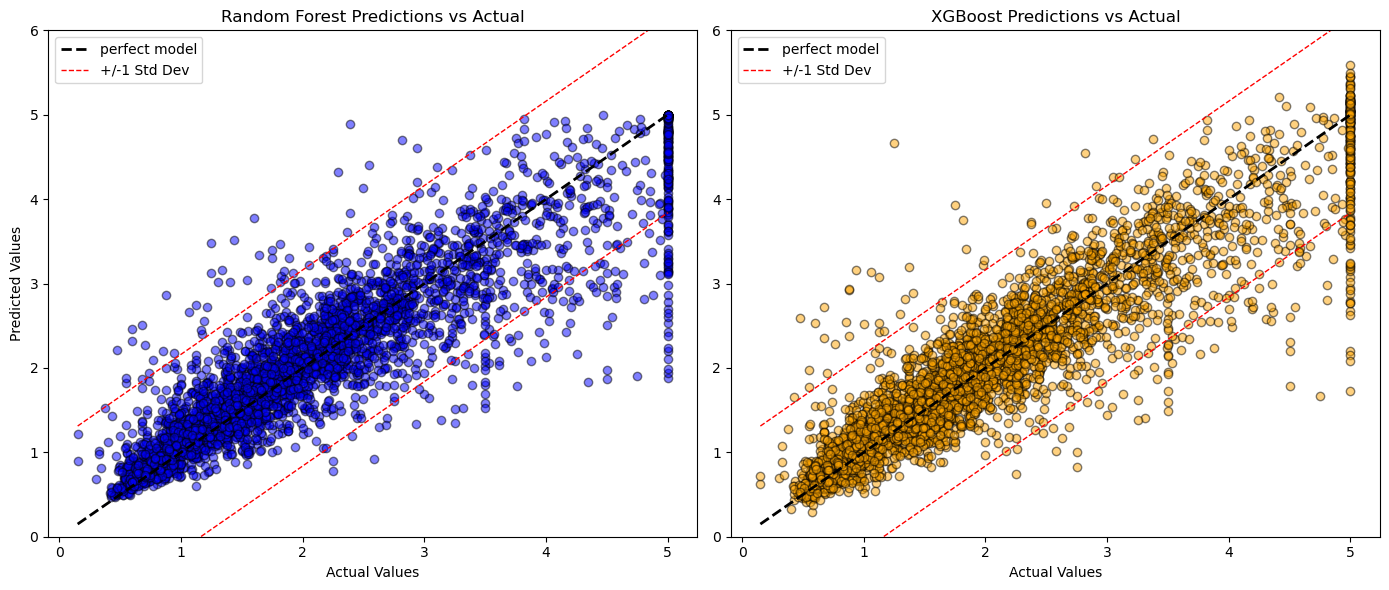

In [32]:
plt.figure(figsize=(14,6))

# Random Forest plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.5, color="blue",ec='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2,label="perfect model")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_y, y_test.max() + std_y], 'r--', lw=1, label="+/-1 Std Dev")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_y, y_test.max() - std_y], 'r--', lw=1, )
plt.ylim(0,6)
plt.title("Random Forest Predictions vs Actual")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()


# XGBoost plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color="orange",ec='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2,label="perfect model")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_y, y_test.max() + std_y], 'r--', lw=1, label="+/-1 Std Dev")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_y, y_test.max() - std_y], 'r--', lw=1, )
plt.ylim(0,6)
plt.title("XGBoost Predictions vs Actual")
plt.xlabel("Actual Values")
plt.legend()
plt.tight_layout()
plt.show()